# Spatial Multi-band Decoding

Question: Does adding lower-frequency amplitude bands (theta 4-8, alpha 8-12, beta 13-30 Hz) to the 70-150 Hz high-gamma feature improve spatial-location decoding, and do any of the lower bands decode location on their own?

In [1]:
import sys, warnings, hashlib
from pathlib import Path
from dataclasses import replace

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

ROOT = Path.cwd()
REPO = ROOT if (ROOT / "scripts" / "seeg_io.py").exists() else ROOT.parent
sys.path.insert(0, str(REPO / "scripts"))

from seeg_io import SEEGDataset
from decoding import _svm, sloo_folds, cv_score, time_resolved_scores, window_score, CANONICAL_BANDS
from spectral_exp import (viable_region_pool, build_band_tensors, subset_bands,
                          run_condition, summary_row, CUE_WINDOW, DELAY_WINDOW)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

BANDS       = list(CANONICAL_BANDS.values())          # theta, alpha, beta, high_gamma
BAND_NAMES  = list(CANONICAL_BANDS)
HG_IDX      = BAND_NAMES.index("high_gamma")          # == 3
REGIONS     = ["Dorsal", "Ventral"]

# ---- FULL CONFIGURATION (records the config actually run) ----
REF          = "Laplacian"
N_RESAMPLES  = 10
DOWNSAMPLE   = 10            # matches the baseline pipeline (PDF: downsample by 10 samples)
N_CV_REPEATS = 5             # SLOO folds = 3 trials/class x 5 = 15
N_CHANNELS   = 80
C_SVM        = 0.1
print(f"config: N_RESAMPLES={N_RESAMPLES} DOWNSAMPLE={DOWNSAMPLE} "
      f"N_CV_REPEATS={N_CV_REPEATS} N_CHANNELS={N_CHANNELS} ref={REF}")
print(f"windows: cue={CUE_WINDOW}s  delay={DELAY_WINDOW}s  (approximate — no epoch markers in file)")

ds = SEEGDataset(REPO / "data" / "Prefrontal_Delay_3_6_sec_Session.mat")
POOLS   = {r: viable_region_pool(ds, r, required_classes=9) for r in REGIONS}
for r in REGIONS:
    print(f"  {r}: {len(POOLS[r])} viable channels")

import time
_t0 = time.time()
TENSORS = {r: build_band_tensors(ds, POOLS[r], n_resamples=N_RESAMPLES,
                                 n_channels=N_CHANNELS, ref=REF, bands=BANDS,
                                 downsample=DOWNSAMPLE, seed=0)
           for r in REGIONS}
print(f"built {N_RESAMPLES} x {len(REGIONS)} band tensors in {time.time()-_t0:.0f}s; "
      f"shape {TENSORS['Dorsal'][0].X.shape}  (n_train per SLOO fold = "
      f"{TENSORS['Dorsal'][0].X.shape[0] - 9})")
CHANCE = TENSORS["Dorsal"][0].chance
TIME_S = TENSORS["Dorsal"][0].time_s


config: N_RESAMPLES=10 DOWNSAMPLE=10 N_CV_REPEATS=5 N_CHANNELS=80 ref=Laplacian
windows: cue=(1.0, 2.0)s  delay=(2.5, 5.5)s  (approximate — no epoch markers in file)


  Dorsal: 124 viable channels
  Ventral: 78 viable channels


built 10 x 2 band tensors in 161s; shape (27, 312, 308)  (n_train per SLOO fold = 18)


## Design checks

### Paired comparison

Every feature condition is a column subset of the same 4-band tensor (`subset_bands`). The checks below confirm the trials, channels, `y`, time axis, SLOO folds and the HG feature block are byte-identical across conditions.

In [2]:
pop = TENSORS["Dorsal"][0]
nb = pop.n_bands
hg   = subset_bands(pop, [HG_IDX])
fus  = subset_bands(pop, [0, 1, 2, 3])
hgt  = subset_bands(pop, [HG_IDX, 0])
f_hg  = sloo_folds(hg.y,  n_repeats=N_CV_REPEATS, seed=0)
f_fus = sloo_folds(fus.y, n_repeats=N_CV_REPEATS, seed=0)

print("y identical (HG vs fusion vs HG+θ):",
      np.array_equal(hg.y, fus.y), np.array_equal(hg.y, hgt.y))
print("time axis identical:", np.array_equal(hg.time_s, fus.time_s))
print("channels identical:", hg.channel_indices == fus.channel_indices == hgt.channel_indices)
print("SLOO folds identical across conditions (same y, same seed):",
      all(np.array_equal(a[0], b[0]) and np.array_equal(a[1], b[1]) for a, b in zip(f_hg, f_fus)))
print("HG columns inside fusion  == standalone HG:", np.allclose(fus.X[:, HG_IDX::nb, :], hg.X))
print("HG columns inside HG+θ    == standalone HG:", np.allclose(hgt.X[:, 1::2, :], hg.X))
print(f"n folds = {len(f_hg)},  n_train per fold = {len(f_hg[0][0])},  n_test = {len(f_hg[0][1])}")
print("\nPaired-comparison check: this multi-band comparison is a genuine paired "
      "comparison — one shared tensor, column subsetting, identical y / time / folds.")


y identical (HG vs fusion vs HG+θ): True True
time axis identical: True
channels identical: True
SLOO folds identical across conditions (same y, same seed): True
HG columns inside fusion  == standalone HG: True
HG columns inside HG+θ    == standalone HG: True
n folds = 15,  n_train per fold = 18,  n_test = 9

Paired-comparison check: this multi-band comparison is a genuine paired comparison — one shared tensor, column subsetting, identical y / time / folds.


### Fold-wise PCA has no test leakage

`make_pipeline(StandardScaler, PCA, LinearSVC)` is rebuilt and `.fit()` inside
each fold, so the scaler and PCA see training data only. The diagnostics below
confirm the two conditions use different feature and latent matrices and that the
component count is legal for the fold training-set size.

In [3]:
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC

def ck(a):
    return hashlib.md5(np.ascontiguousarray(a).tobytes()).hexdigest()[:12]

WIN = (1.1, 1.9)                       # static decoding window
def static_win(p):
    m = (p.time_s >= WIN[0]) & (p.time_s < WIN[1])
    return p.X[:, :, m].mean(axis=2)

Xhg, Xfus = static_win(hg), static_win(fus)
folds = sloo_folds(pop.y, n_repeats=N_CV_REPEATS, seed=0)
n_train = len(folds[0][0])
max_rank = min(n_train - 1, Xfus.shape[1])           # centered data
N_COMP = min(10, max_rank)

print(f"X(HG)     shape {Xhg.shape}   checksum {ck(Xhg)}")
print(f"X(fusion) shape {Xfus.shape}  checksum {ck(Xfus)}")
print(f"X(HG) == X(fusion)?  {np.array_equal(Xhg, Xfus)}   (must be False)")
print(f"n_train per SLOO fold = {n_train}   max legal PCA rank (centered) = {max_rank}")
print(f"PCA n_components used here = {N_COMP}\n")

def fold_pca_diag(X, y, ncomp):
    accs, latent_ck, evr = [], [], []
    for tr, te in folds:
        pipe = make_pipeline(StandardScaler(), PCA(n_components=ncomp),
                             LinearSVC(C=C_SVM, dual="auto", max_iter=5000))
        pipe.fit(X[tr], y[tr])                       # fit on TRAIN only
        accs.append(np.mean(pipe.predict(X[te]) == y[te]))
        sc, pc = pipe.named_steps["standardscaler"], pipe.named_steps["pca"]
        latent_ck.append(ck(pc.transform(sc.transform(X[tr]))))
        evr.append(pc.explained_variance_ratio_.sum())
    return float(np.mean(accs)), latent_ck[0], float(np.mean(evr))

a_hg,  lc_hg,  evr_hg  = fold_pca_diag(Xhg,  pop.y, N_COMP)
a_fus, lc_fus, evr_fus = fold_pca_diag(Xfus, pop.y, N_COMP)
print(f"HG     PCA-{N_COMP} acc {a_hg:.3f}   fold0 latent checksum {lc_hg}   Σexplained-var {evr_hg:.3f}")
print(f"fusion PCA-{N_COMP} acc {a_fus:.3f}   fold0 latent checksum {lc_fus}   Σexplained-var {evr_fus:.3f}")
print(f"latent matrices identical between conditions?  {lc_hg == lc_fus}   (must be False)")
print("\n"
      "The fold-wise scaler+PCA has no test leakage. Its PCA component count, however, "
      f"({N_COMP} of ≤{max_rank}) barely reduces dimensionality relative to the "
      f"{n_train}-sample training set — a weak 'dimension-matched' test. "
      "decode_spatial_multiband_reduction.ipynb does this properly "
      "with PCA(2/5/10) and PLS.")


X(HG)     shape (27, 78)   checksum 6a6d4072748a
X(fusion) shape (27, 312)  checksum bfa5b795d944
X(HG) == X(fusion)?  False   (must be False)
n_train per SLOO fold = 18   max legal PCA rank (centered) = 17
PCA n_components used here = 10

HG     PCA-10 acc 0.074   fold0 latent checksum 390947e0e017   Σexplained-var 0.779
fusion PCA-10 acc 0.170   fold0 latent checksum b9bfa22aea4e   Σexplained-var 0.686
latent matrices identical between conditions?  False   (must be False)

The fold-wise scaler+PCA has no test leakage. Its PCA component count, however, (10 of ≤17) barely reduces dimensionality relative to the 18-sample training set — a weak 'dimension-matched' test. decode_spatial_multiband_reduction.ipynb does this properly with PCA(2/5/10) and PLS.


## Experiment - 8 feature conditions, both regions

N_RESAMPLES=10 / DOWNSAMPLE=10 / N_CV_REPEATS=5.

In [4]:
CONDITIONS = {
    "theta":       [BAND_NAMES.index("theta")],
    "alpha":       [BAND_NAMES.index("alpha")],
    "beta":        [BAND_NAMES.index("beta")],
    "HG":          [HG_IDX],
    "HG+theta":    [HG_IDX, BAND_NAMES.index("theta")],
    "HG+alpha":    [HG_IDX, BAND_NAMES.index("alpha")],
    "HG+beta":     [HG_IDX, BAND_NAMES.index("beta")],
    "HG+theta+alpha+beta": [0, 1, 2, 3],
}

import time
RES = {}
for region in REGIONS:
    RES[region] = {}
    t0 = time.time()
    for name, idx in CONDITIONS.items():
        RES[region][name] = run_condition(TENSORS[region], idx, lambda: _svm(C_SVM),
                                          n_cv_repeats=N_CV_REPEATS, seed=0)
    print(f"{region} done in {time.time()-t0:.0f}s")


Dorsal done in 621s


Ventral done in 625s


In [5]:
for region in REGIONS:
    print(f"\n===== {region}  (chance {CHANCE:.3f}) =====")
    for name in CONDITIONS:
        print("  " + summary_row(name, RES[region][name]))



===== Dorsal  (chance 0.111) =====
  theta                       p=  78  p/n_train=  4.33  cue=0.088±0.045  delay=0.113±0.034  peak=0.247@1.81s
  alpha                       p=  78  p/n_train=  4.33  cue=0.106±0.033  delay=0.119±0.060  peak=0.265@2.66s
  beta                        p=  78  p/n_train=  4.33  cue=0.084±0.033  delay=0.075±0.043  peak=0.272@2.33s
  HG                          p=  78  p/n_train=  4.33  cue=0.116±0.046  delay=0.127±0.047  peak=0.268@2.46s
  HG+theta                    p= 156  p/n_train=  8.67  cue=0.098±0.049  delay=0.130±0.041  peak=0.253@3.56s
  HG+alpha                    p= 156  p/n_train=  8.67  cue=0.111±0.051  delay=0.125±0.053  peak=0.267@2.31s
  HG+beta                     p= 156  p/n_train=  8.67  cue=0.125±0.033  delay=0.101±0.043  peak=0.267@2.98s
  HG+theta+alpha+beta         p= 312  p/n_train= 17.33  cue=0.119±0.042  delay=0.123±0.042  peak=0.258@2.92s

===== Ventral  (chance 0.111) =====
  theta                       p=  78  p/n_train=  4.33 

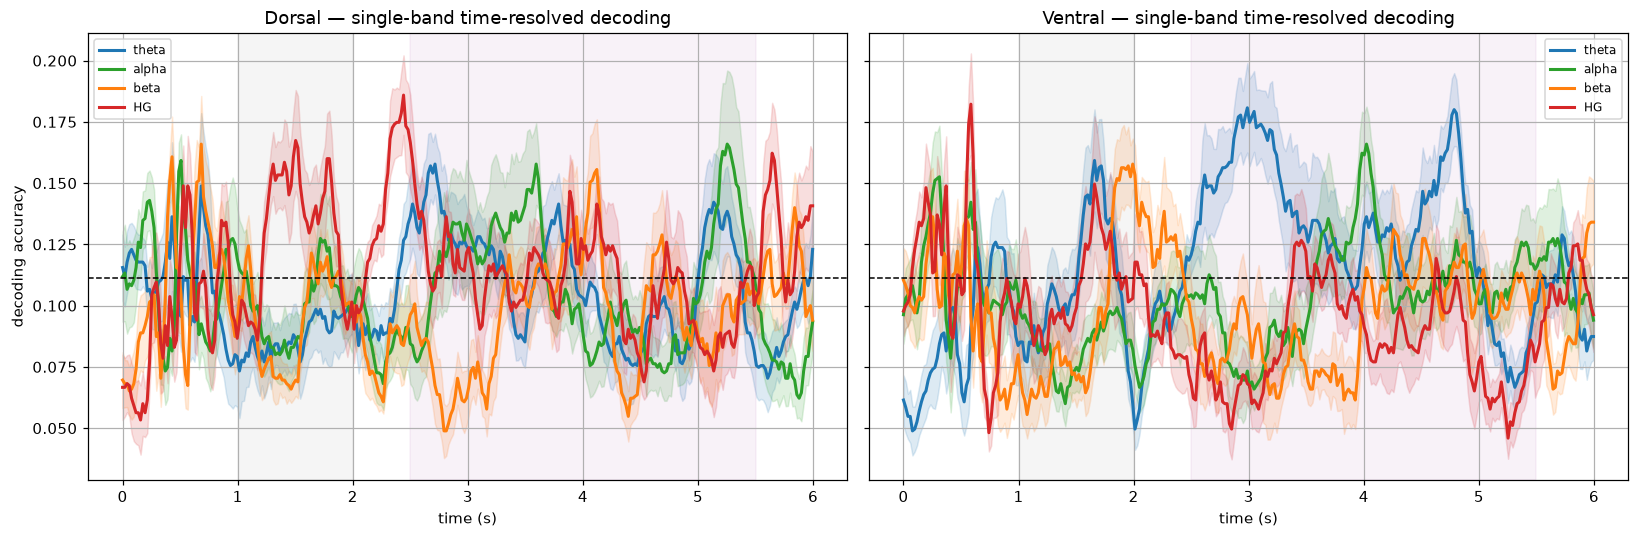

In [6]:
# time-resolved curves — single bands
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
cols = {"theta": "tab:blue", "alpha": "tab:green", "beta": "tab:orange", "HG": "tab:red"}
for ax, region in zip(axes, REGIONS):
    for name in ["theta", "alpha", "beta", "HG"]:
        d = RES[region][name]
        ax.plot(d["time_s"], d["curve_mean"], color=cols[name], lw=2, label=name)
        ax.fill_between(d["time_s"], d["curve_mean"] - d["curve_sem"],
                        d["curve_mean"] + d["curve_sem"], color=cols[name], alpha=0.15)
    ax.axhline(CHANCE, color="k", ls="--", lw=1)
    ax.axvspan(*CUE_WINDOW, color="grey", alpha=0.08)
    ax.axvspan(*DELAY_WINDOW, color="purple", alpha=0.05)
    ax.set_title(f"{region} — single-band time-resolved decoding")
    ax.set_xlabel("time (s)"); ax.legend(fontsize=8)
axes[0].set_ylabel("decoding accuracy")
plt.tight_layout()


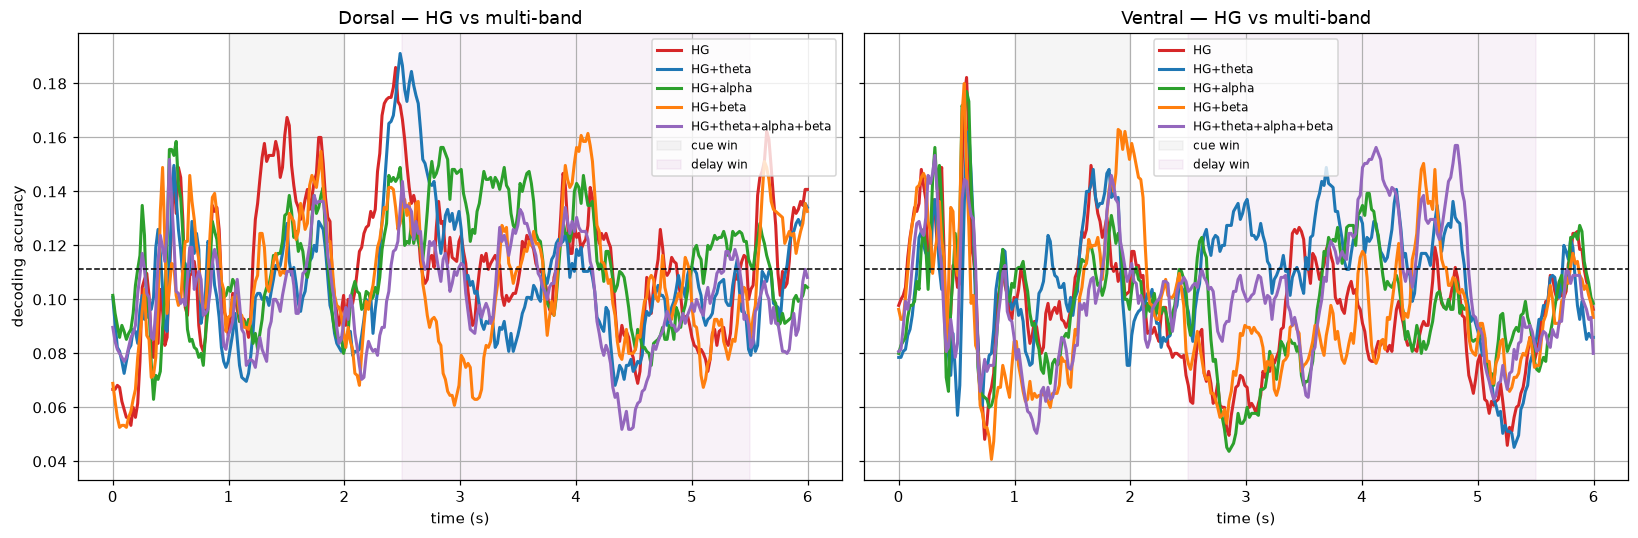

In [7]:
# time-resolved curves — HG vs fusion vs HG+single
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
palette = {"HG": "tab:red", "HG+theta": "tab:blue", "HG+alpha": "tab:green",
           "HG+beta": "tab:orange", "HG+theta+alpha+beta": "tab:purple"}
for ax, region in zip(axes, REGIONS):
    for name, col in palette.items():
        d = RES[region][name]
        ax.plot(d["time_s"], d["curve_mean"], color=col, lw=2, label=name)
    ax.axhline(CHANCE, color="k", ls="--", lw=1)
    ax.axvspan(*CUE_WINDOW, color="grey", alpha=0.08, label="cue win")
    ax.axvspan(*DELAY_WINDOW, color="purple", alpha=0.05, label="delay win")
    ax.set_title(f"{region} — HG vs multi-band"); ax.set_xlabel("time (s)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("decoding accuracy")
plt.tight_layout()


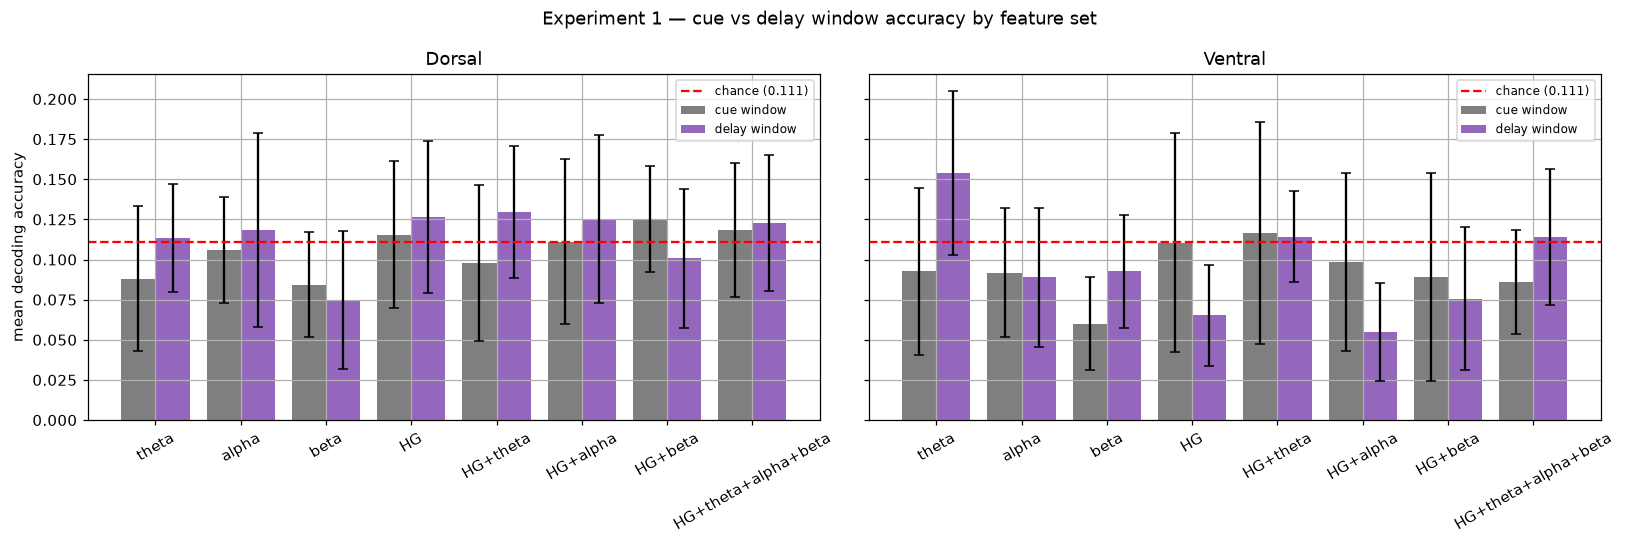

In [8]:
# bar summary — cue-window vs delay-window mean accuracy, both regions
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
names = list(CONDITIONS)
x = np.arange(len(names))
for ax, region in zip(axes, REGIONS):
    cue   = [RES[region][n]["cue_mean"] for n in names]
    delay = [RES[region][n]["delay_mean"] for n in names]
    cue_e = [RES[region][n]["cue_std"] for n in names]
    del_e = [RES[region][n]["delay_std"] for n in names]
    ax.bar(x - 0.2, cue,   0.4, yerr=cue_e, capsize=3, label="cue window",   color="tab:gray")
    ax.bar(x + 0.2, delay, 0.4, yerr=del_e, capsize=3, label="delay window", color="tab:purple")
    ax.axhline(CHANCE, color="red", ls="--", label=f"chance ({CHANCE:.3f})")
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=30)
    ax.set_title(f"{region}"); ax.legend(fontsize=8)
axes[0].set_ylabel("mean decoding accuracy")
fig.suptitle("Experiment 1 — cue vs delay window accuracy by feature set")
plt.tight_layout()
